# Benchmark Evaluation: LCC-FASD Dataset
Evaluate Silent-FAS pipeline on LCC-FASD evaluation set (7,580 images).

In [20]:
import os
import sys
import cv2
import numpy as np
from tqdm import tqdm

fas_root = os.path.abspath("../third_party/Silent-Face-Anti-Spoofing")
sys.path.insert(0, fas_root)
os.chdir(fas_root)

from src.anti_spoof_predict import AntiSpoofPredict

predictor = AntiSpoofPredict(device_id=0)
model_dir = "resources/anti_spoof_models"
model_paths = sorted([os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")])

FileNotFoundError: [WinError 3] 지정된 경로를 찾을 수 없습니다: 'c:\\Users\\gmission\\Desktop\\face-defense\\third_party\\third_party\\Silent-Face-Anti-Spoofing'

In [ ]:
eval_root = os.path.abspath("../../data/raw/LCC_FASD/LCC_FASD_evaluation")
real_dir = os.path.join(eval_root, "real")
spoof_dir = os.path.join(eval_root, "spoof")

labels = []
scores = []

# Evaluate real images
real_files = sorted(os.listdir(real_dir))
for fname in tqdm(real_files, desc="Real"):
    img = cv2.imread(os.path.join(real_dir, fname))
    if img is None:
        continue
    try:
        bbox = predictor.get_bbox(img)
        x, y, w, h = bbox
        face = cv2.resize(img[y:y+h, x:x+w], (80, 80))
        total = 0.0
        for path in model_paths:
            result = predictor.predict(face, path)
            total += result[0][1]
        score = total / len(model_paths)
        labels.append(1)
        scores.append(score)
    except:
        continue

# Evaluate spoof images
spoof_files = sorted(os.listdir(spoof_dir))
for fname in tqdm(spoof_files, desc="Spoof"):
    img = cv2.imread(os.path.join(spoof_dir, fname))
    if img is None:
        continue
    try:
        bbox = predictor.get_bbox(img)
        x, y, w, h = bbox
        face = cv2.resize(img[y:y+h, x:x+w], (80, 80))
        total = 0.0
        for path in model_paths:
            result = predictor.predict(face, path)
            total += result[0][1]
        score = total / len(model_paths)
        labels.append(0)
        scores.append(score)
    except:
        continue

labels = np.array(labels)
scores = np.array(scores)
print(f"Evaluated: {len(labels)} images ({(labels==1).sum()} real, {(labels==0).sum()} spoof)")

Real:   0%|          | 0/314 [00:00<?, ?it/s]c:\Users\gmission\Desktop\face-defense\third_party\Silent-Face-Anti-Spoofing\src\anti_spoof_predict.py:91: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  result = F.softmax(result).cpu().numpy()
Spoof: 100%|██████████| 7266/7266 [17:27<00:00,  6.94it/s]

Evaluated: 7577 images (314 real, 7263 spoof)


In [ ]:
from face_defense.evaluation.metrics import compute_auc, compute_eer, compute_apcer, compute_bpcer, compute_acer

preds = (scores >= 0.5).astype(int)

auc = compute_auc(labels, scores)
eer = compute_eer(labels, scores)
apcer = compute_apcer(labels, preds)
bpcer = compute_bpcer(labels, preds)
acer = compute_acer(apcer, bpcer)

print(f"AUC:   {auc:.4f}")
print(f"EER:   {eer:.4f}")
print(f"APCER: {apcer:.4f}")
print(f"BPCER: {bpcer:.4f}")
print(f"ACER:  {acer:.4f}")

AUC:   0.7757
EER:   0.3032
APCER: 0.2701
BPCER: 0.3439
ACER:  0.3070


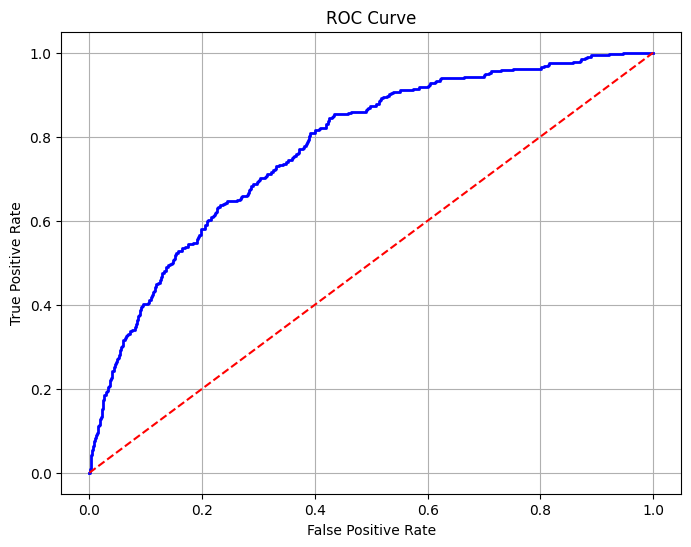

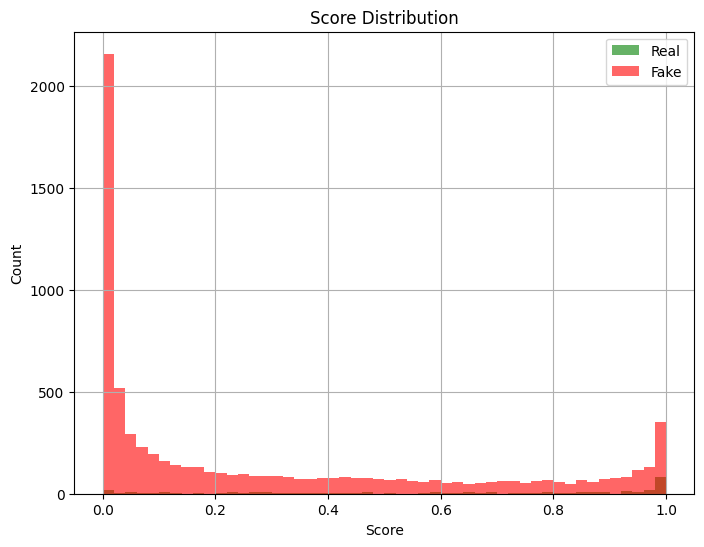

In [ ]:
from face_defense.evaluation.visualization import plot_roc_curve, plot_score_distribution

plot_roc_curve(labels, scores)
plot_score_distribution(labels, scores)

## Results

### Silent-FAS Baseline (Pretrained, threshold=0.5)

| Metric | Value |
|--------|-------|
| AUC    | 0.7757 |
| EER    | 0.3032 |
| APCER  | 0.2701 |
| BPCER  | 0.3439 |
| ACER   | 0.3070 |

## CDCN Benchmark (CelebA-Spoof trained, threshold=0.5)

In [ ]:
import os
import sys
import numpy as np
import torch
import cv2
from tqdm import tqdm

sys.path.insert(0, os.path.abspath(".."))

from face_defense.models.anti_spoof.cdcn_model import CDCN
from face_defense.evaluation.metrics import compute_auc, compute_eer, compute_apcer, compute_bpcer, compute_acer
from face_defense.evaluation.visualization import plot_roc_curve, plot_score_distribution

# Load CDCN model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CDCN(in_channels=3, theta=0.7)
state_dict = torch.load("../checkpoints/cdcn_best.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print(f"Device: {device}, Model loaded")

Device: cuda, Model loaded


In [ ]:
from insightface.app import FaceAnalysis
face_app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
face_app.prepare(ctx_id=0, det_size=(640, 640))

detect_count = 0
fallback_count = 0

def cdcn_predict(img_path):
    global detect_count, fallback_count
    img = cv2.imread(img_path)
    if img is None:
        return None

    faces = face_app.get(img)

    if len(faces) > 0:
        detect_count += 1
        face_info = max(faces, key=lambda f: f.det_score)
        x1, y1, x2, y2 = face_info.bbox.astype(int)
        h, w = y2 - y1, x2 - x1
        margin = int(0.2 * max(w, h))
        x1 = max(0, x1 - margin)
        y1 = max(0, y1 - margin)
        x2 = min(img.shape[1], x2 + margin)
        y2 = min(img.shape[0], y2 + margin)
        face = img[y1:y2, x1:x2]
    else:
        fallback_count += 1
        face = img

    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (256, 256))
    face = face.astype(np.float32) / 255.0
    tensor = torch.from_numpy(face).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        depth_map = model(tensor)
    return depth_map.mean().item()

eval_root = "../data/raw/LCC_FASD/LCC_FASD_evaluation"
real_dir = os.path.join(eval_root, "real")
spoof_dir = os.path.join(eval_root, "spoof")

cdcn_labels = []
cdcn_scores = []

for fname in tqdm(sorted(os.listdir(real_dir)), desc="Real"):
    score = cdcn_predict(os.path.join(real_dir, fname))
    if score is not None:
        cdcn_labels.append(1)
        cdcn_scores.append(score)

for fname in tqdm(sorted(os.listdir(spoof_dir)), desc="Spoof"):
    score = cdcn_predict(os.path.join(spoof_dir, fname))
    if score is not None:
        cdcn_labels.append(0)
        cdcn_scores.append(score)

cdcn_labels = np.array(cdcn_labels)
cdcn_scores = np.array(cdcn_scores)
print(f"Evaluated: {len(cdcn_labels)} images ({(cdcn_labels==1).sum()} real, {(cdcn_labels==0).sum()} spoof)")
print(f"Detected: {detect_count}, Fallback: {fallback_count}")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\gmission/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvid

Spoof: 100%|██████████| 7266/7266 [01:39<00:00, 72.98it/s]

Evaluated: 7580 images (314 real, 7266 spoof)
Detected: 1010, Fallback: 6570


In [ ]:
cdcn_scores_inv = 1 - cdcn_scores
cdcn_preds = (cdcn_scores_inv >= 0.5).astype(int)

cdcn_auc = compute_auc(cdcn_labels, cdcn_scores_inv)
cdcn_eer = compute_eer(cdcn_labels, cdcn_scores_inv)
cdcn_apcer = compute_apcer(cdcn_labels, cdcn_preds)
cdcn_bpcer = compute_bpcer(cdcn_labels, cdcn_preds)
cdcn_acer = compute_acer(cdcn_apcer, cdcn_bpcer)

print(f"AUC:   {cdcn_auc:.4f}")
print(f"EER:   {cdcn_eer:.4f}")
print(f"APCER: {cdcn_apcer:.4f}")
print(f"BPCER: {cdcn_bpcer:.4f}")
print(f"ACER:  {cdcn_acer:.4f}")

AUC:   0.8097
EER:   0.2331
APCER: 0.1854
BPCER: 0.3185
ACER:  0.2519


In [ ]:
from sklearn.metrics import roc_curve

# Find optimal threshold at EER point
fpr, tpr, thresholds = roc_curve(cdcn_labels, 1 - cdcn_scores)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
optimal_threshold = thresholds[eer_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")

# Recalculate with optimal threshold
cdcn_scores_inv = 1 - cdcn_scores
cdcn_preds_opt = (cdcn_scores_inv >= optimal_threshold).astype(int)

apcer = compute_apcer(cdcn_labels, cdcn_preds_opt)
bpcer = compute_bpcer(cdcn_labels, cdcn_preds_opt)
acer = compute_acer(apcer, bpcer)

print(f"APCER: {apcer:.4f}")
print(f"BPCER: {bpcer:.4f}")
print(f"ACER:  {acer:.4f}")

Optimal threshold: 0.3696
APCER: 0.2331
BPCER: 0.2325
ACER:  0.2328


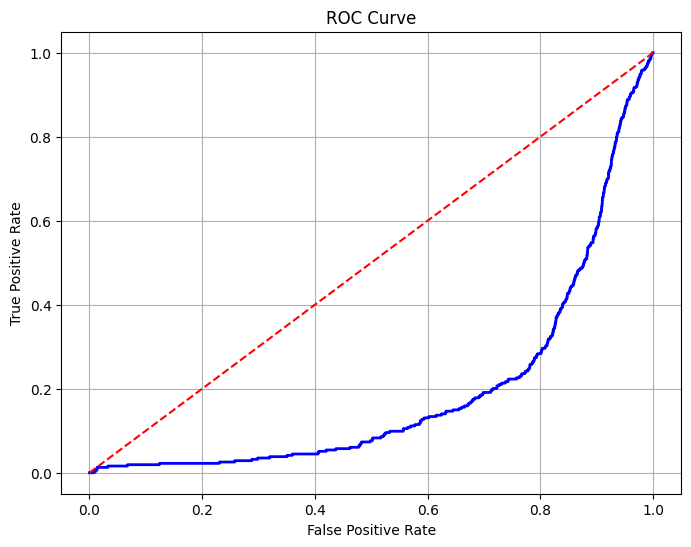

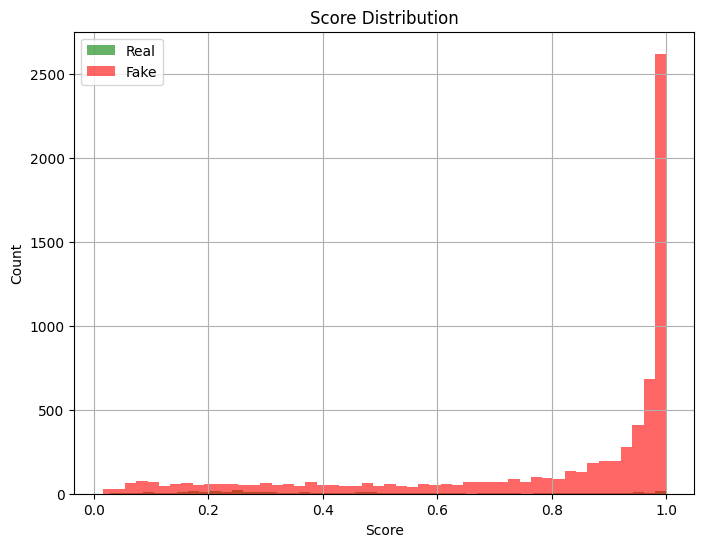

In [ ]:
plot_roc_curve(cdcn_labels, cdcn_scores)
plot_score_distribution(cdcn_labels, cdcn_scores)

## Comparison

| Metric | Silent-FAS | CDCN |
|--------|-----------|------|
| AUC    | 0.7757    | 0.8174 |
| EER    | 0.3032    | 0.2285 |
| APCER  | 0.2701    | 0.1901 |
| BPCER  | 0.3439    | 0.3025 |
| ACER   | 0.3070    | 0.2463 |

In [ ]:
# RVF10K validation set benchmark
rvf_real_dir = "C:/Users/gmission/Downloads/anti-spoof-test-dataset2/rvf10k/valid/real"
rvf_fake_dir = "C:/Users/gmission/Downloads/anti-spoof-test-dataset2/rvf10k/valid/fake"

rvf_labels = []
rvf_scores = []

for fname in tqdm(sorted(os.listdir(rvf_real_dir)), desc="Real"):
    img = cv2.imread(os.path.join(rvf_real_dir, fname))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        depth_map = model(tensor)
    rvf_labels.append(1)
    rvf_scores.append(depth_map.mean().item())

for fname in tqdm(sorted(os.listdir(rvf_fake_dir)), desc="Fake"):
    img = cv2.imread(os.path.join(rvf_fake_dir, fname))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        depth_map = model(tensor)
    rvf_labels.append(0)
    rvf_scores.append(depth_map.mean().item())

rvf_labels = np.array(rvf_labels)
rvf_scores = np.array(rvf_scores)

print(f"Evaluated: {len(rvf_labels)} images ({(rvf_labels==1).sum()} real, {(rvf_labels==0).sum()} fake)")
print(f"Real scores  - mean: {rvf_scores[rvf_labels==1].mean():.4f}")
print(f"Fake scores  - mean: {rvf_scores[rvf_labels==0].mean():.4f}")

# Auto detect score direction
if rvf_scores[rvf_labels==1].mean() < rvf_scores[rvf_labels==0].mean():
    print("Score inverted: applying 1 - score")
    rvf_scores = 1 - rvf_scores

rvf_preds = (rvf_scores >= 0.5).astype(int)
print(f"\nAUC:   {compute_auc(rvf_labels, rvf_scores):.4f}")
print(f"EER:   {compute_eer(rvf_labels, rvf_scores):.4f}")
print(f"APCER: {compute_apcer(rvf_labels, rvf_preds):.4f}")
print(f"BPCER: {compute_bpcer(rvf_labels, rvf_preds):.4f}")
print(f"ACER:  {compute_acer(compute_apcer(rvf_labels, rvf_preds), compute_bpcer(rvf_labels, rvf_preds)):.4f}")

Fake: 100%|██████████| 1500/1500 [00:05<00:00, 289.61it/s]

Evaluated: 3000 images (1500 real, 1500 fake)
Real scores  - mean: 0.4378
Fake scores  - mean: 0.4598
Score inverted: applying 1 - score

AUC:   0.5522
EER:   0.4607
APCER: 0.6247
BPCER: 0.3173
ACER:  0.4710


In [ ]:
# CipLab Real and Fake Face Detection benchmark
ciplab_real = "C:/Users/gmission/Downloads/anti-spoof-test-dataset/real_and_fake_face/training_real"
ciplab_fake = "C:/Users/gmission/Downloads/anti-spoof-test-dataset/real_and_fake_face/training_fake"

cip_labels = []
cip_scores = []

for fname in tqdm(sorted(os.listdir(ciplab_real)), desc="Real"):
    img = cv2.imread(os.path.join(ciplab_real, fname))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device) 
    with torch.no_grad():
        depth_map = model(tensor)
    cip_labels.append(1)
    cip_scores.append(depth_map.mean().item())

for fname in tqdm(sorted(os.listdir(ciplab_fake)), desc="Fake"):
    img = cv2.imread(os.path.join(ciplab_fake, fname))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device) 
    with torch.no_grad():
        depth_map = model(tensor)
    cip_labels.append(0)
    cip_scores.append(depth_map.mean().item())

cip_labels = np.array(cip_labels)
cip_scores = np.array(cip_scores)

print(f"Evaluated: {len(cip_labels)} images ({(cip_labels==1).sum()} real, {(cip_labels==0).sum()} fake)")
print(f"Real scores  - mean: {cip_scores[cip_labels==1].mean():.4f}")       
print(f"Fake scores  - mean: {cip_scores[cip_labels==0].mean():.4f}")       

if cip_scores[cip_labels==1].mean() < cip_scores[cip_labels==0].mean():     
    print("Score inverted: applying 1 - score")
    cip_scores = 1 - cip_scores

cip_preds = (cip_scores >= 0.5).astype(int)
print(f"\nAUC:   {compute_auc(cip_labels, cip_scores):.4f}")
print(f"EER:   {compute_eer(cip_labels, cip_scores):.4f}")
print(f"APCER: {compute_apcer(cip_labels, cip_preds):.4f}")
print(f"BPCER: {compute_bpcer(cip_labels, cip_preds):.4f}")
print(f"ACER:  {compute_acer(compute_apcer(cip_labels, cip_preds), compute_bpcer(cip_labels, cip_preds)):.4f}")

SyntaxError: unterminated string literal (detected at line 50) (3562026852.py, line 50)